### IMPORTS

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

### REVISTAS

#### General

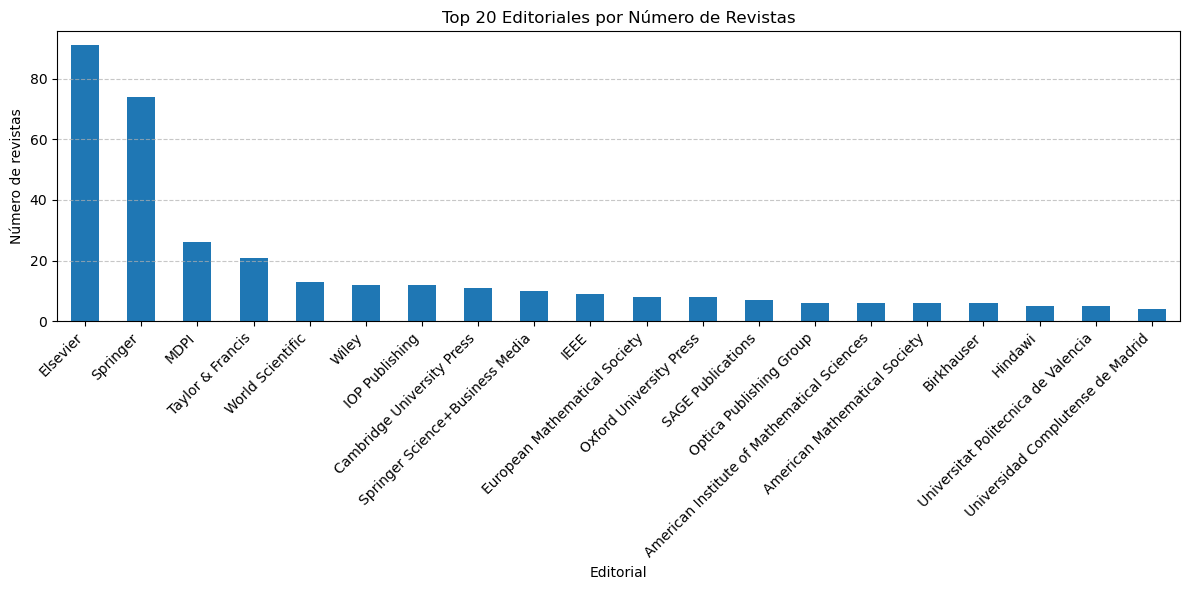

In [4]:
df_revistas = pd.read_csv("Revistas.csv", encoding="latin1", sep=";", engine='python')
df_revistas_1 = df_revistas.iloc[:, 0].str.split(",", expand=True)
df_revistas_1.columns = ["Revista", "Identificador", "Editorial", "Extra"]
conteo_editoriales = df_revistas_1["Editorial"].value_counts()

plt.figure(figsize=(12, 6))
conteo_editoriales.head(20).plot(kind='bar')
plt.title("Top 20 Editoriales por Número de Revistas")
plt.xlabel("Editorial")
plt.ylabel("Número de revistas")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Universidades

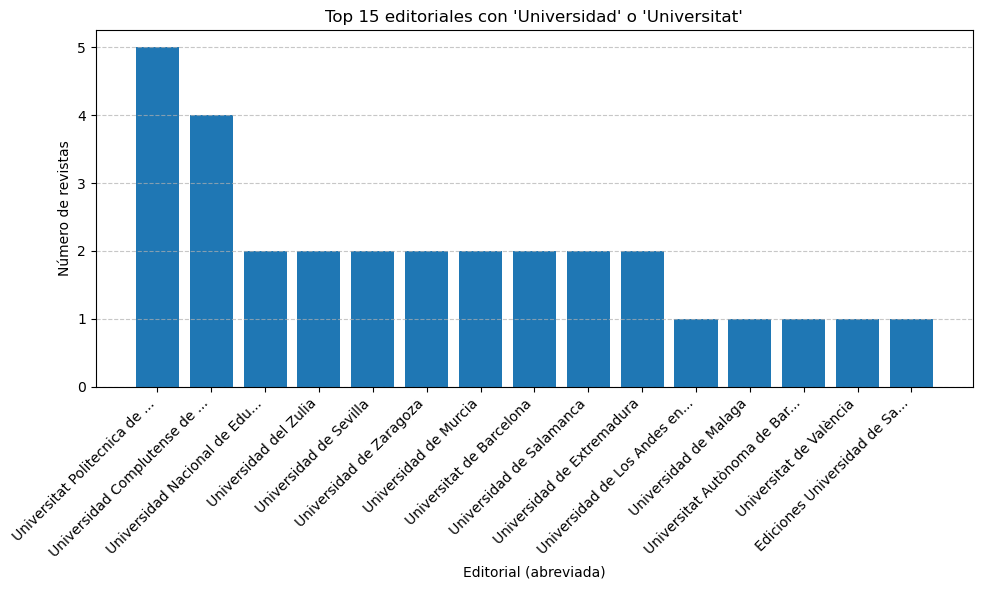

In [8]:
df_revistas_2 = df_revistas.iloc[:, 0].str.split(",", expand=True)
df_revistas_2.columns = ["Revista", "Identificador", "Editorial", "Extra"]

editoriales_universidad = df_revistas_2[
    df_revistas_2["Editorial"].str.contains("Universidad|Universitat", case=False, na=False)
]

conteo = editoriales_universidad["Editorial"].value_counts().head(15)

etiquetas = [e if len(e) <= 30 else e[:27] + "..." for e in conteo.index]

plt.figure(figsize=(10, 6))
plt.bar(etiquetas, conteo.values)
plt.title("Top 15 editoriales con 'Universidad' o 'Universitat'")
plt.xlabel("Editorial (abreviada)")
plt.ylabel("Número de revistas")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Investigadores

In [14]:
csvs_modificados = [
    "1ha_publicado_en_AlegreGC_editoriales.csv",
    "1ha_publicado_en_ArnauNAR_editoriales.csv",
    "1ha_publicado_en_ArroyoJM_editoriales.csv",
    "1ha_publicado_en_ArroyoJP_editoriales.csv",
    "1ha_publicado_en_BiviaC_editoriales.csv",
    "1ha_publicado_en_BonetSJ_editoriales.csv",
    "1ha_publicado_en_CalabuigRJM_editoriales.csv",
    "1ha_publicado_en_CobolloGC_editoriales.csv",
    "1ha_publicado_en_ConejeroJA_editoriales.csv",
    "1ha_publicado_en_FelipeRMJ_editoriales.csv",
    "1ha_publicado_en_FernandezCCPJ_editoriales.csv",
    "1ha_publicado_en_FerrerSA_editoriales.csv",
    "1ha_publicado_en_GarciaRLM_editoriales.csv",
    "1ha_publicado_en_GuijarroMF_editoriales.csv",
    "1ha_publicado_en_GuiraoSAJ_editoriales.csv",
    "1ha_publicado_en_HoyasCS_editoriales.csv",
    "1ha_publicado_en_IsidroSJJM_editoriales.csv",
    "1ha_publicado_en_JordaME_editoriales.csv",
    "1ha_publicado_en_JornetCD_editoriales.csv",
    "1ha_publicado_en_LazaroNM_editoriales.csv",
    "1ha_publicado_en_LopezMA_editoriales.csv",
    "1ha_publicado_en_LopezPM_editoriales.csv",
    "1ha_publicado_en_MartinezJF_editoriales.csv",
    "1ha_publicado_en_MartinezPA_editoriales.csv",
    "1ha_publicado_en_MartinezUMJ_editoriales.csv",
    "1ha_publicado_en_MilianEC_editoriales.csv",
    "1ha_publicado_en_MonserratDFJ_editoriales.csv",
    "1ha_publicado_en_MontesinosSV_editoriales.csv",
    "1ha_publicado_en_MorillasGS_editoriales.csv",
    "1ha_publicado_en_OrtizSVM_editoriales.csv",
    "1ha_publicado_en_PedrazaAMC_editoriales.csv",
    "1ha_publicado_en_PerisMA_editoriales.csv",
    "1ha_publicado_en_PesetMF_editoriales.csv",
    "1ha_publicado_en_PetrosyanL_editoriales.csv",
    "1ha_publicado_en_QuilisSA_editoriales.csv",
    "1ha_publicado_en_RodenasEF_editoriales.csv",
    "1ha_publicado_en_RodriguezLJ_editoriales.csv",
    "1ha_publicado_en_RomeroGV_editoriales.csv",
    "1ha_publicado_en_SanchezPEA_editoriales.csv",
    "1ha_publicado_en_SanchisLJM_editoriales.csv",
    "1ha_publicado_en_SevillaPP_editoriales.csv",
    "1ha_publicado_en_TiradoPP_editoriales.csv"
]

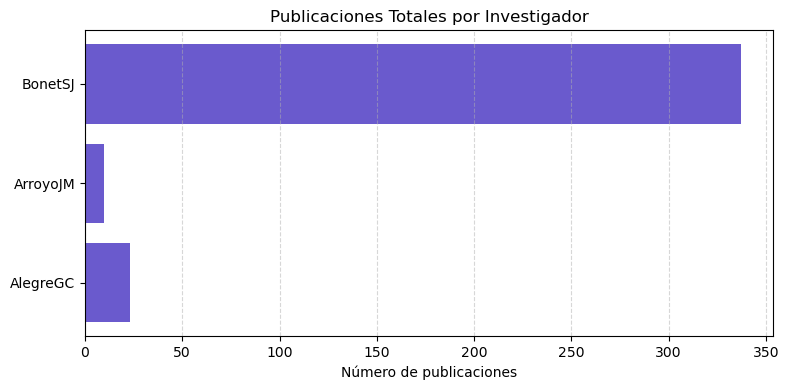

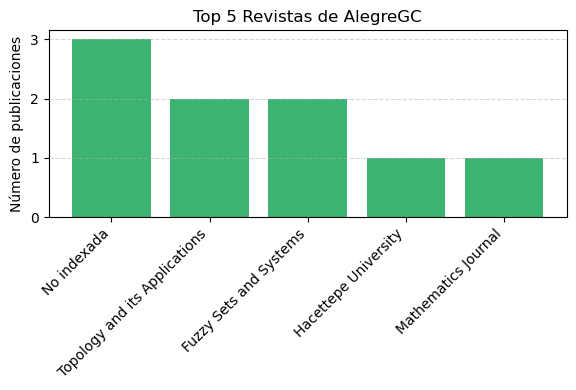

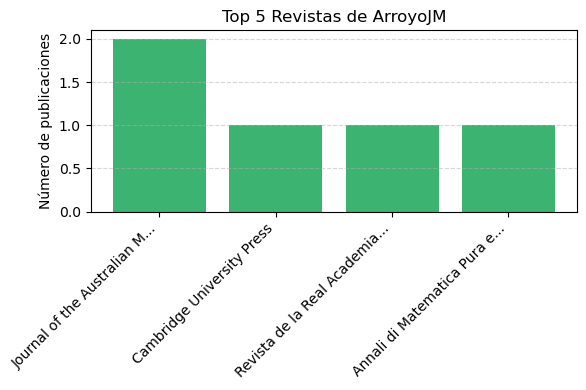

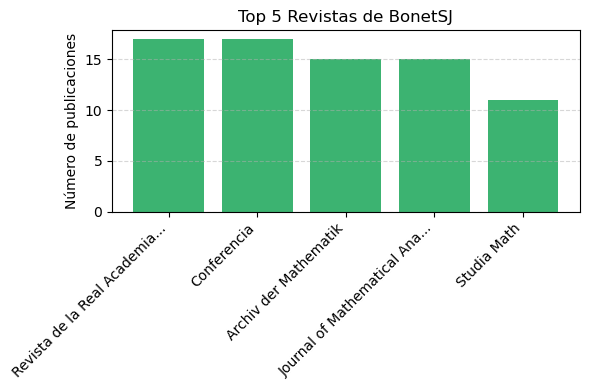

In [ ]:
investigadores_a_analizar = ["AlegreGC", "ArroyoJM", "BonetSJ"]

csvs_modificados = [
    "1ha_publicado_en_AlegreGC_editoriales.csv",
    "1ha_publicado_en_ArroyoJM_editoriales.csv",
    "1ha_publicado_en_BonetSJ_editoriales.csv"
]

publicaciones_totales = {}
editoriales_por_investigador = {}

for nombre in investigadores_a_analizar:
    archivo = f"1ha_publicado_en_{nombre}_editoriales.csv"
    if archivo in csvs_modificados:
        df = pd.read_csv(archivo, encoding="latin-1")
        publicaciones_totales[nombre] = len(df)
        top_editoriales = df["journal"].value_counts().head(5)
        editoriales_por_investigador[nombre] = top_editoriales

plt.figure(figsize=(8, 4))
plt.barh(list(publicaciones_totales.keys()), list(publicaciones_totales.values()), color="slateblue")
plt.title("Publicaciones Totales por Investigador")
plt.xlabel("Número de publicaciones")
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

for nombre, conteo in editoriales_por_investigador.items():
    plt.figure(figsize=(6, 4))
    
    # Acortar nombres largos
    etiquetas = [j if len(j) <= 30 else j[:27] + "..." for j in conteo.index]
    
    plt.bar(etiquetas, conteo.values, color="mediumseagreen")
    plt.title(f"Top 5 Revistas de {nombre}")
    plt.ylabel("Número de publicaciones")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()


### AREAS

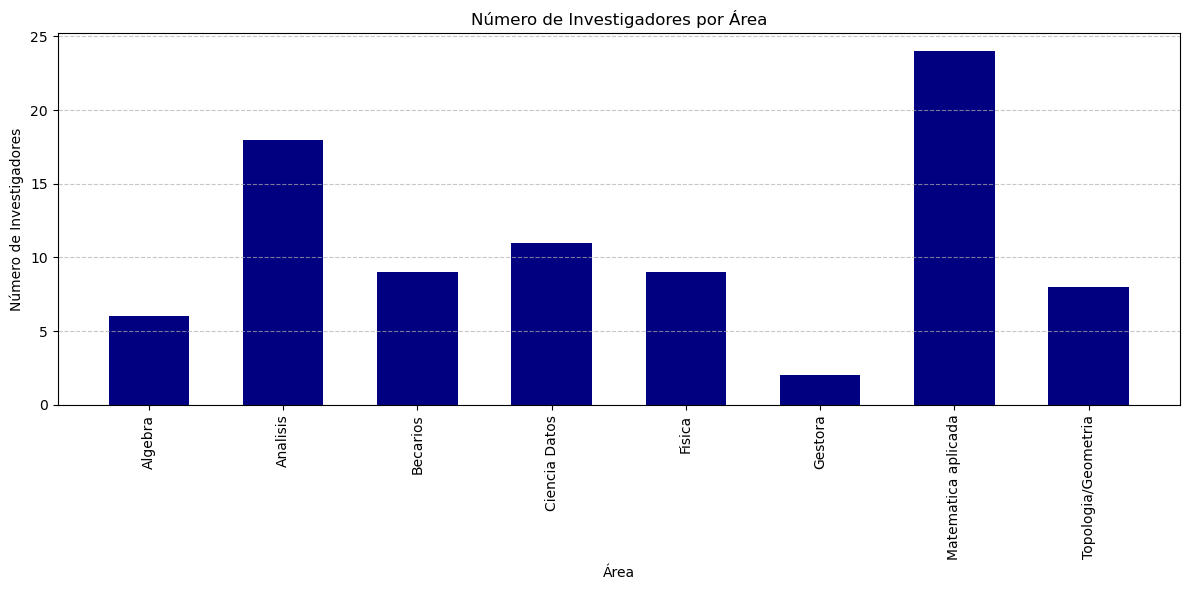

In [13]:
# Cargar datos
df_es_parte_de = pd.read_csv("es_parte_de_limpio_listas.csv", encoding="utf-8")
df_areas = pd.read_csv("Areas.csv", encoding="utf-8")
df_areas.columns = ["nombre_area", "id_area"]

# Separar listas en filas
df_es_parte_de["Areas"] = df_es_parte_de["Areas"].astype(str).str.strip("[]").str.replace("'", "").str.split(", ")
df_exploded = df_es_parte_de.explode("Areas")
df_exploded["Areas"] = df_exploded["Areas"].str.replace('"', '').str.strip()

# Hacer merge usando nombre del área
df_merged = df_exploded.merge(df_areas, left_on="Areas", right_on="nombre_area", how="left")

# Contar número de investigadores por área
conteo_areas = df_merged["nombre_area"].value_counts().sort_index()

# Graficar
plt.figure(figsize=(12, 6))
plt.bar(conteo_areas.index, conteo_areas.values, width=0.6, color='navy')
plt.xticks(rotation=90)
plt.title("Número de Investigadores por Área")
plt.xlabel("Área")
plt.ylabel("Número de Investigadores")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()